In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sns



In [2]:
data=pd.read_csv('insurance.csv')

In [3]:
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
data.sex.replace({'female':0,'male':1},inplace=True)

C:\Users\AdminIT\AppData\Local\Temp\ipykernel_49212\3233640189.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.sex.replace({'female':0,'male':1},inplace=True)
C:\Users\AdminIT\AppData\Local\Temp\ipykernel_49212\3233640189.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.sex.replace(

In [5]:
data.smoker.replace({'yes':1,'no':0},inplace=True)

C:\Users\AdminIT\AppData\Local\Temp\ipykernel_49212\419288219.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.smoker.replace({'yes':1,'no':0},inplace=True)
C:\Users\AdminIT\AppData\Local\Temp\ipykernel_49212\419288219.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.smoker.replace({

In [6]:
encoded_data=pd.get_dummies(data,dtype=int)

In [7]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
encoded_data.duplicated().sum()

np.int64(1)

In [9]:
encoded_data.drop_duplicates(inplace=True)

In [10]:
encoded_data.isna().sum()

age                 0
sex                 0
bmi                 0
children            0
smoker              0
charges             0
region_northeast    0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

In [11]:
x=encoded_data[['age','sex','bmi']]
y=encoded_data[['charges']]

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=12)

In [14]:
from sklearn.linear_model import LinearRegression
charges_predictor=LinearRegression()

In [15]:
charges_predictor.fit(x_train,y_train)

LinearRegression()

In [16]:
from math import sqrt
from sklearn.metrics import mean_squared_error,r2_score

In [17]:
y_train_predictor=charges_predictor.predict(x_train)    

In [18]:
mean_squared_error(y_train,y_train_predictor)

121205575.21511526

In [19]:
sqrt(mean_squared_error(y_train, y_train_predictor))

11009.340362397525

In [20]:
r2_score(y_train,y_train_predictor)

0.12118349975056641

In [21]:
y_test_predictor=charges_predictor.predict(x_test)

In [22]:
sqrt(mean_squared_error(y_test,y_test_predictor))

12668.69428975325

In [23]:
r2_score(y_test,y_test_predictor)

0.10440005864477875

In [24]:
def charge(age,sex,bmi):
    return charges_predictor.predict([[age,sex,bmi]])

In [ ]:
Age=float(input('enter your age here::'))
Sex=float(input('enter your gender here::'))
Bmi =float(input('enter your Bmi here::'))
predicted_charges=charge(Age,Sex,Bmi)
print("Predicted Insurance Charges:", predicted_charges)

enter your age here:: 54
enter yoyr gender here:: 1
enter your Bmi here:: 368


Predicted Insurance Charges: [[121049.518169]]


C:\Users\AdminIT\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


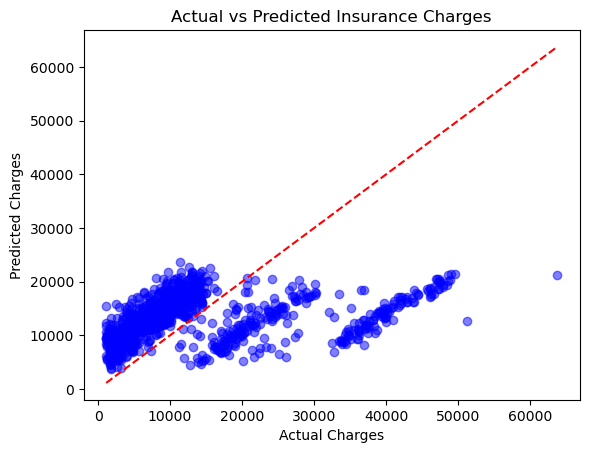

In [26]:
plt.scatter(y_train, y_train_predictor, color='blue', alpha=0.5)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color='red', linestyle='--')
plt.show()